In [19]:
import numpy as np
import pandas as pd
import kagglehub
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL, MSTL
from sklearn.metrics import mean_absolute_percentage_error
from typing import Union
from statsmodels.tsa.arima.model import ARIMA 
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product
from tqdm import tqdm
from tqdm import tqdm_notebook
from prophet import Prophet
from statsmodels.stats.diagnostic import acorr_ljungbox

In [2]:
# We start by downloading the dataset
path = kagglehub.dataset_download("arjunbhaybhang/marine-institute-tide-prediction-dataset")

print("Path to dataset files:", path)

files_in_directory = os.listdir(path)
print("Archivos en el directorio:", files_in_directory)

csv_file_path = os.path.join(path, 'Tide Prediction.csv')

data = pd.read_csv(csv_file_path)
data = data.iloc[1:]#The first row of the dataset is titles.

print(data.head())

Path to dataset files: C:\Users\angel\.cache\kagglehub\datasets\arjunbhaybhang\marine-institute-tide-prediction-dataset\versions\1
Archivos en el directorio: ['Tide Prediction.csv']


C:\Users\angel\AppData\Local\Temp\ipykernel_6320\4283588312.py:11: DtypeWarning: Columns (1,2,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(csv_file_path)


                   time   longitude  latitude               stationID  \
1  2017-01-01T00:10:00Z  -10.101596  53.95219  Achill_Island_MODELLED   
2  2017-01-01T00:20:00Z  -10.101596  53.95219  Achill_Island_MODELLED   
3  2017-01-01T00:30:00Z  -10.101596  53.95219  Achill_Island_MODELLED   
4  2017-01-01T00:40:00Z  -10.101596  53.95219  Achill_Island_MODELLED   
5  2017-01-01T00:50:00Z  -10.101596  53.95219  Achill_Island_MODELLED   

  Water_Level Water_Level_ODM  
1        1.34           -1.23  
2         1.3           -1.27  
3        1.26           -1.31  
4        1.23           -1.34  
5        1.22           -1.35  


## Time Series Analysis

In [3]:
print('First row starts in: ' + data['time'].min(), 'last row is :' + data['time'].max())
# Data from 2017 to 2020
# 10 minutes margen between oone line to the next one

First row starts in: 2017-01-01T00:00:00Z last row is :2020-01-01T00:20:00Z


In [4]:
#Adjust the data types
data['time'] = pd.to_datetime(data['time'])
data['longitude'] = pd.to_numeric(data['longitude'])
data['latitude'] = pd.to_numeric(data['latitude'])
data['Water_Level'] = pd.to_numeric(data['Water_Level'])
data['Water_Level_ODM'] = pd.to_numeric(data['Water_Level_ODM'])

In [5]:
#We want only analyze data from an specific port!!
#We chose this but the port chose do not affect the analysis
data_located = data[data['stationID'] == 'Dingle_Harbour_MODELLED']


#Because of the high execution time, lets only consider data from one year
train = data_located[data_located['time'].dt.year == 2017]

In [6]:
#test data will be first week of 2018 (horizon)
data_2018 = data_located.loc[data_located['time'].dt.year == 2018]  # First week of 2018
test = data_2018[:1008] 
len(test) #Should be 1008: 6x24x7 

1008

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52559 entries, 1997291 to 2049849
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   time             52559 non-null  datetime64[ns, UTC]
 1   longitude        52559 non-null  float64            
 2   latitude         52559 non-null  float64            
 3   stationID        52559 non-null  object             
 4   Water_Level      52559 non-null  float64            
 5   Water_Level_ODM  52559 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(4), object(1)
memory usage: 2.8+ MB


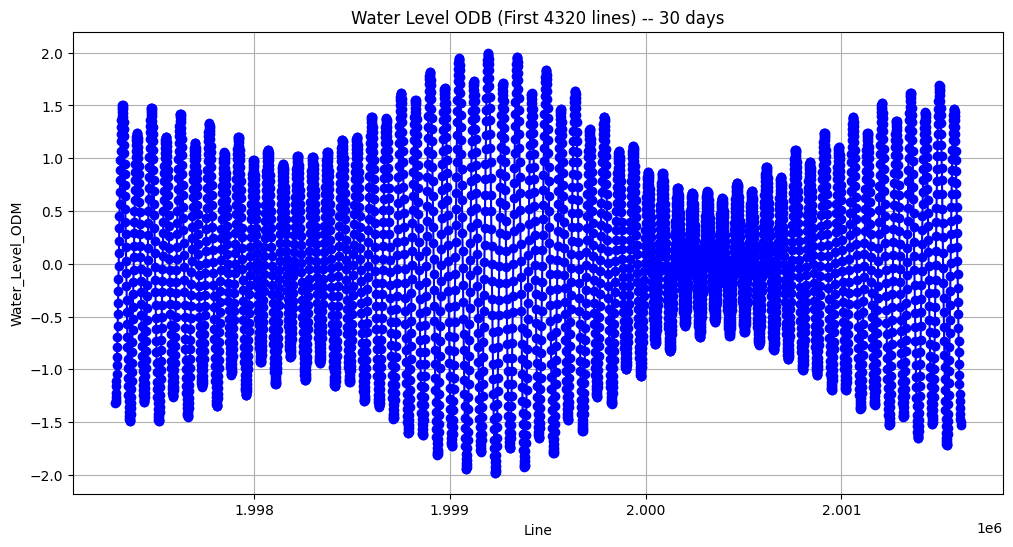

In [8]:
primeras_100 = train.head(4320)

# This is the water lever over a 30 days, we can see it seems to follow a patern
# According to theory, wides change every 2'76 weeks
plt.figure(figsize=(12, 6))
plt.plot(primeras_100['Water_Level_ODM'], marker='o', linestyle='-', color='blue')
plt.title('Water Level ODB (First 4320 lines) -- 30 days')
plt.xlabel('Line')
plt.ylabel('Water_Level_ODM')
plt.grid(True)
plt.show()

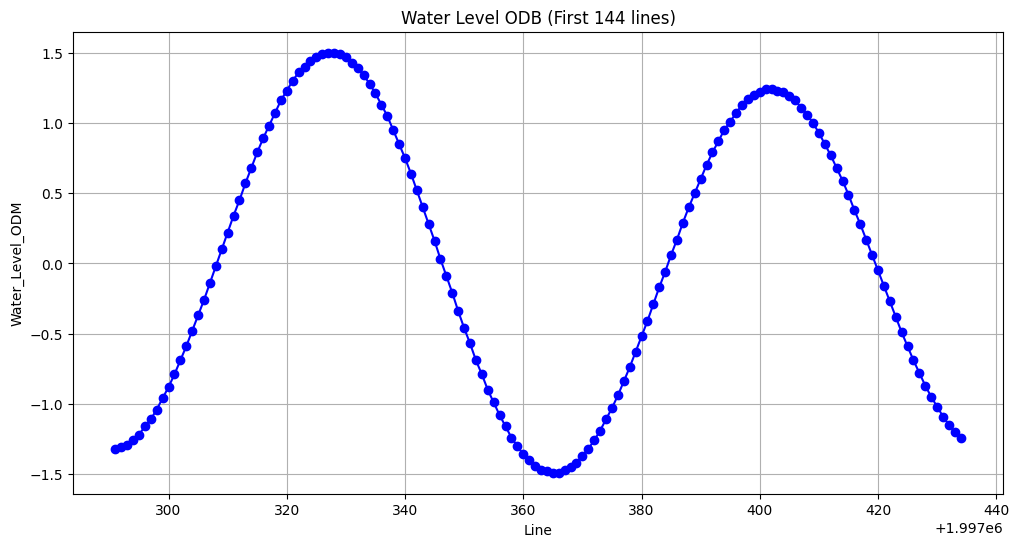

In [9]:
primeras_100 = train.head(144)

# This is the water lever over a day, we can see it seems to follow a patern
# This shows perfectly that in a day there are 2 high tides and 2 low tides
plt.figure(figsize=(12, 6))
plt.plot(primeras_100['Water_Level_ODM'], marker='o', linestyle='-', color='blue')
plt.title('Water Level ODB (First 144 lines)')
plt.xlabel('Line')
plt.ylabel('Water_Level_ODM')
plt.grid(True)
plt.show()

According to the theory, wides contain multiple different seasonalities at the same time. They usually depend on the ocean and and factors like the place of the sun and the relation with the position of the sun relatively to the moon which are too complex to consider with models we are seeing in class.

- The simple ones we will consider are:

1. First: Semi-Diurnal Tide, 12 hours 25 minutes (74.5 rows)
2. Second: Diurnal Tide, 24 hours 50 minutes (149 rows)
3. Third: Spring-Neap Cycle, 14.76 days (2.125,44 rows)
4. Four: Yearly cycle, 365 days (52.560 rows) interesting but we will not consider for resources limitation

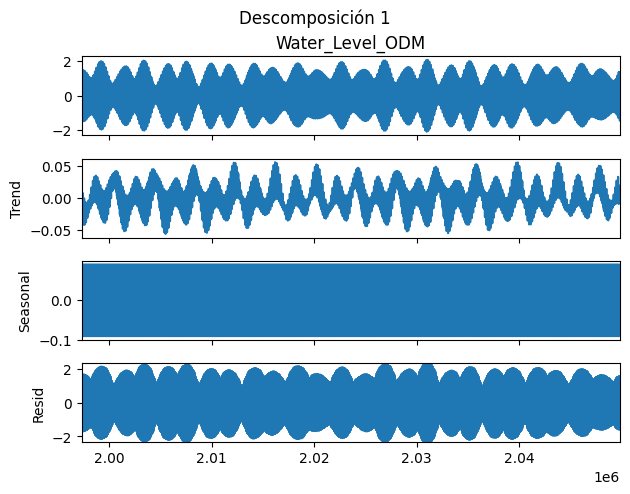

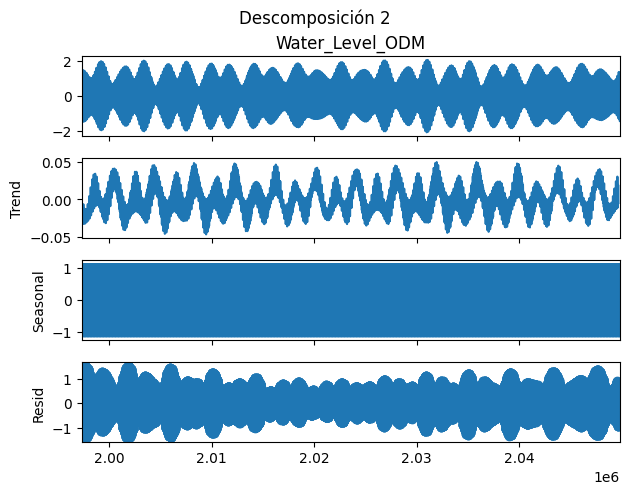

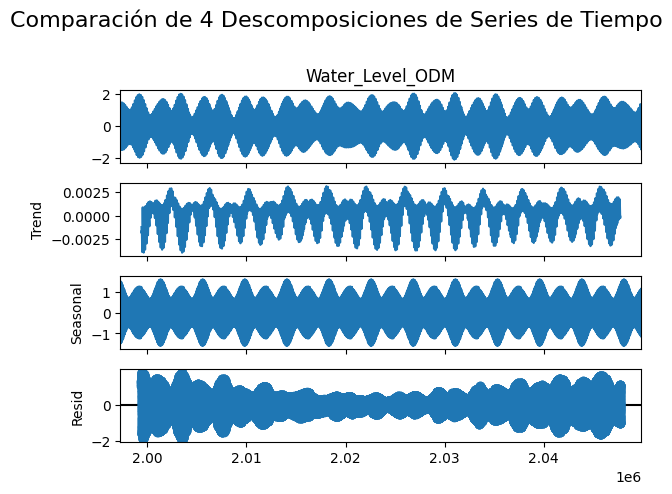

In [10]:
# Decomposition -> will we be abe to find patterns in the data with this seasonalities??

# x must contain 2 complete cycles of the seasonality.
decomposition_1 = seasonal_decompose(train['Water_Level_ODM'], model='additive', period=75*2)
decomposition_2 = seasonal_decompose(train['Water_Level_ODM'], model='additive', period=149*2)
decomposition_3 = seasonal_decompose(train['Water_Level_ODM'], model='additive', period=2125*2)
# decomposition_4 = seasonal_decompose(train['Water_Level_ODM'], model='additive', period=52560*2)

decomposition_1.plot().suptitle('Descomposición 1', x=0.5, y=1.02)
decomposition_2.plot().suptitle('Descomposición 2', x=0.5, y=1.02)
decomposition_3.plot().suptitle('Descomposición 3', x=0.5, y=1.02)
# decomposition_4.plot().suptitle('Descomposición 4', x=0.5, y=1.02)

# Ajustar el espacio entre subplots
plt.tight_layout()

# Título principal
plt.suptitle('Comparación de 4 Descomposiciones de Series de Tiempo', fontsize=16, y=1.02)

plt.show()


Analysis for seasonal_decomposition:

1. Twice a day & Daily season:
    - Trend: close to 0 with small oscilations, stable, not strong increasing or decrasing, cyclic
    - Seasonality: no seasonality detected, this can be because there are more than 1 seasons
    - Residuals: residuals or random noise should be random, but there is an structures and patterns!!

2. Each 14.76 weeks:
    - Trend: mantains close to 0, ver small spikes, not increasing either decreasing
    - Seasonality: The period worked well, clean waves and repeating pattern
    - Residuals: big noise in the edges, probably depends on patarameter we are not considering

In [ ]:
# Deeper decomposition analysis

# mstl = MSTL(train['Water_Level_ODM'], periods=[74*2+1, 149*2, 2125*2+1])
# result = mstl.fit()
# result.plot()

## ARMA

###  Identify the q order for MA

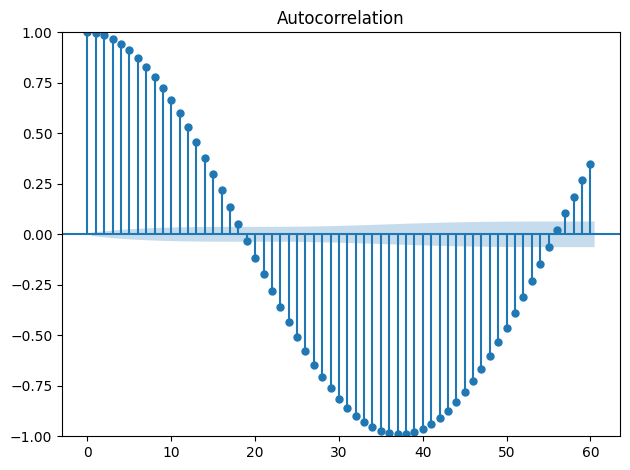

In [17]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(train['Water_Level_ODM'], lags=60);
plt.tight_layout()

ACF plot analysis: 
- ACF and trends: high coefficient for short lags that linearly decreases with longer lags -> there is a trend
- ACF and seasonality: cyclic patters plotted -> there is a seasonality

(we already demonstrated in the previous delivery data is not random-walk by the adf test)

### Identify the p order for the AR

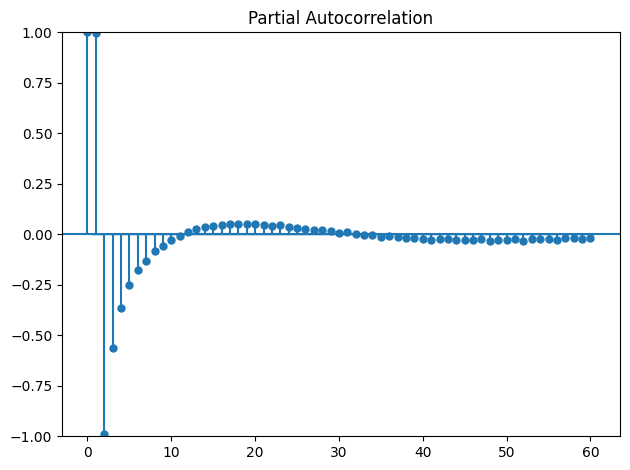

In [18]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(train['Water_Level_ODM'], lags=60);
plt.tight_layout()

Pacf plot analysis:
- Not a pure PA(p) process either as it follows a sinusodial pattern
- Let's try AIC 

### Select model with lowers AIC

In [19]:
ps = range(0, 20, 1) #From 0 to 3 with steps of 1
qs = range(0, 10, 1) #From 0 to 3 with steps of 1

order_list = list(product(ps, qs))

In [20]:
# def optimize_ARMA(endog: Union[pd.Series, list], order_list: list) -> pd.DataFrame:
#     results = []
#     for order in tqdm_notebook(order_list):
#       try:
#           model = SARIMAX(endog, order=(order[0], 0, order[1]), simple_differencing=False).fit(disp=False)
#       except:
#         continue
#       aic = model.aic
#       results.append([order, aic])
#     result_df = pd.DataFrame(results)
#     result_df.columns = ['(p,q)', 'AIC']
#     #Sort in ascending order, lower AIC is better
#     result_df = result_df.sort_values(by='AIC',ascending=True).reset_index(drop=True)
#     return result_df

# result_df = optimize_ARMA(train['Water_Level_ODM'], order_list)
# result_df

0.    (p,q) ---   AIC
1.  (14, 8)	-425208.447910
2.  (13, 8)	-424843.086776
3.  (15, 8)	-371665.628262
4.  (6, 8)	-371663.628263
    ...            ...

### Residuals Analysis for AIC top 1

c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


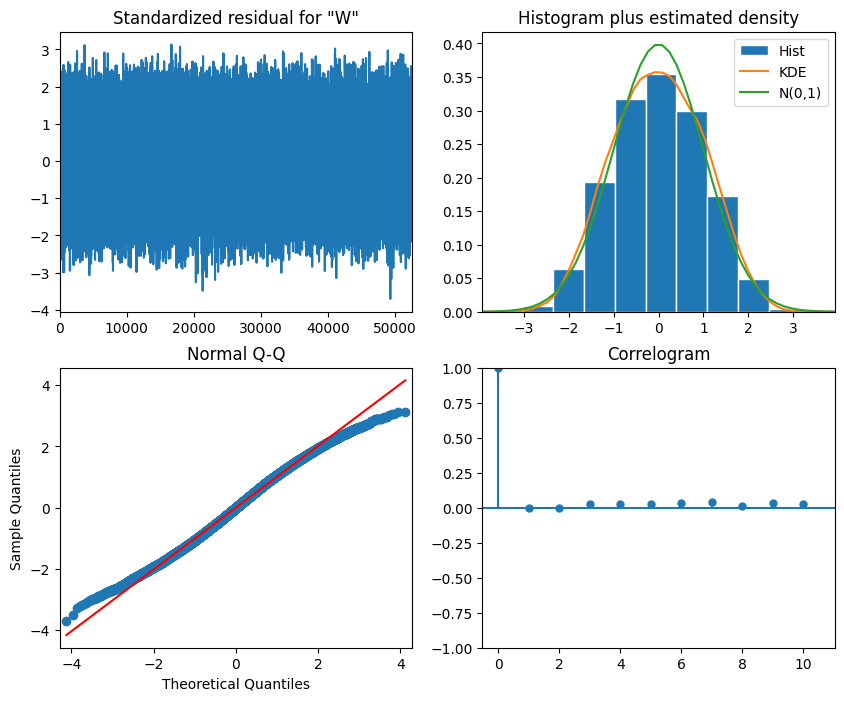

In [18]:
ARMA_model = SARIMAX(train['Water_Level_ODM'], order=(14,0 ,8), simple_differencing=False)
ARMA_model_fit = ARMA_model.fit(disp=False)
ARMA_model_fit.plot_diagnostics(figsize=(10, 8));

- the first plot shows the residuals have the correct shape of white noise, and in the second one the residuals distrubution follows the one it should
- the normal qq plot is not an straight line at all but good enough to accept it
- this correlogram shows there is a lack of correlation between one residual to the next ones

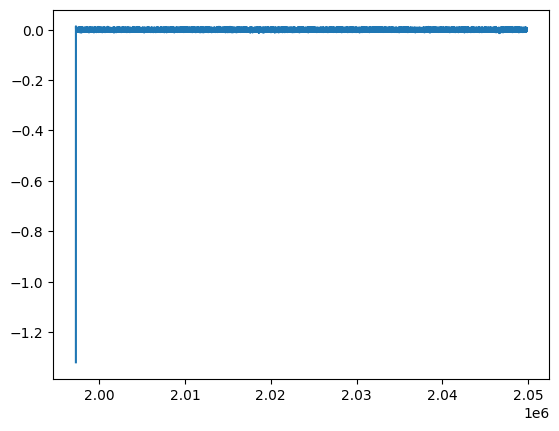

In [ ]:
import matplotlib.pyplot as plt
plt.plot(ARMA_model_fit.resid)
plt.show()

In [ ]:
residuals = ARMA_model_fit.resid #This is were residuals are stored
print( acorr_ljungbox(residuals, np.arange(1, 11, 1)))

      lb_stat  lb_pvalue
1    0.462888   0.496277
2    0.463112   0.793298
3    3.079591   0.379516
4    5.214783   0.265961
5    5.217534   0.389913
6   12.851046   0.045463
7   18.232561   0.010964
8   18.253817   0.019402
9   24.539961   0.003525
10  28.602589   0.001445


- 1-5 p-val>0.05 means model is correctly fitting for predicting in shorter lags
- for bigger lags the model shows autocorrelation -> model misses seasonality

### Residual Analysis for AIC (6, 8) Top 4

c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


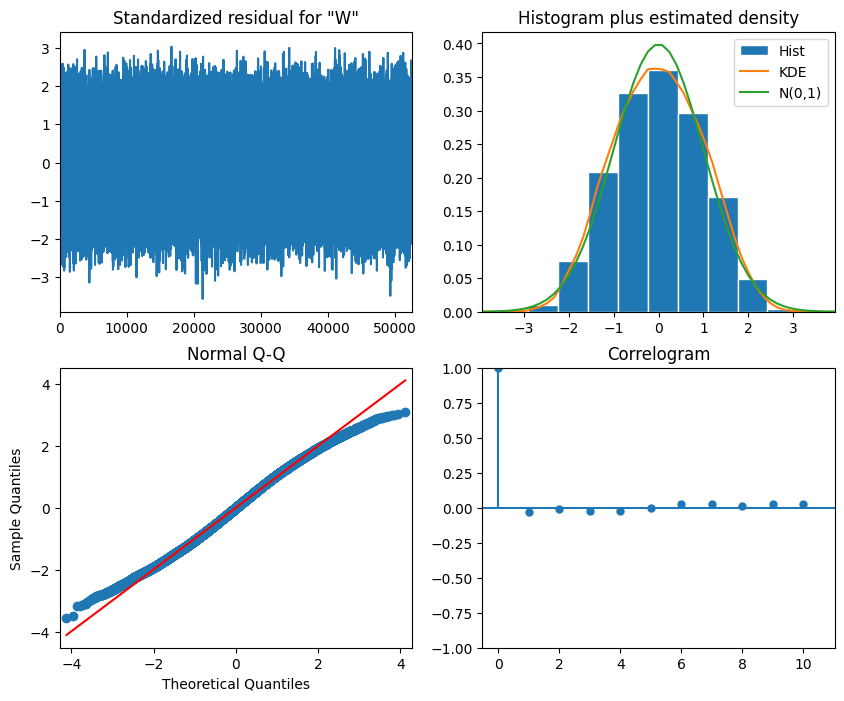

In [17]:
ARMA_model_2 = SARIMAX(train['Water_Level_ODM'], order=(6,0 ,8), simple_differencing=False)
ARMA_model_fit_2 = ARMA_model_2.fit(disp=False)
ARMA_model_fit_2.plot_diagnostics(figsize=(10, 8));

In [18]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = ARMA_model_fit_2.resid #This is were residuals are stored
print( acorr_ljungbox(residuals, np.arange(1, 11, 1)))

      lb_stat  lb_pvalue
1    7.064890   0.007861
2    7.358247   0.025245
3    9.770122   0.020625
4   14.134128   0.006879
5   16.523195   0.005499
6   20.366555   0.002382
7   23.042419   0.001676
8   23.095931   0.003243
9   27.070664   0.001362
10  30.787618   0.000636


According to the residuals: Top 1 outperforms Top 4 !!

## ARIMA

Previous ARMA = ARIMA (d=0) so we will not try ARIMA again or make the AIC test

### 2'76 weeks seasonality

In [ ]:
descomposicion = seasonal_decompose(train['Water_Level_ODM'], model='additive', period=2126)
serie_ajustada = train['Water_Level_ODM'] - descomposicion.seasonal

ARMA_with_seasonality_1 = SARIMAX(serie_ajustada, order=(14,0,8), simple_differencing=False).fit(disp=False)

c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


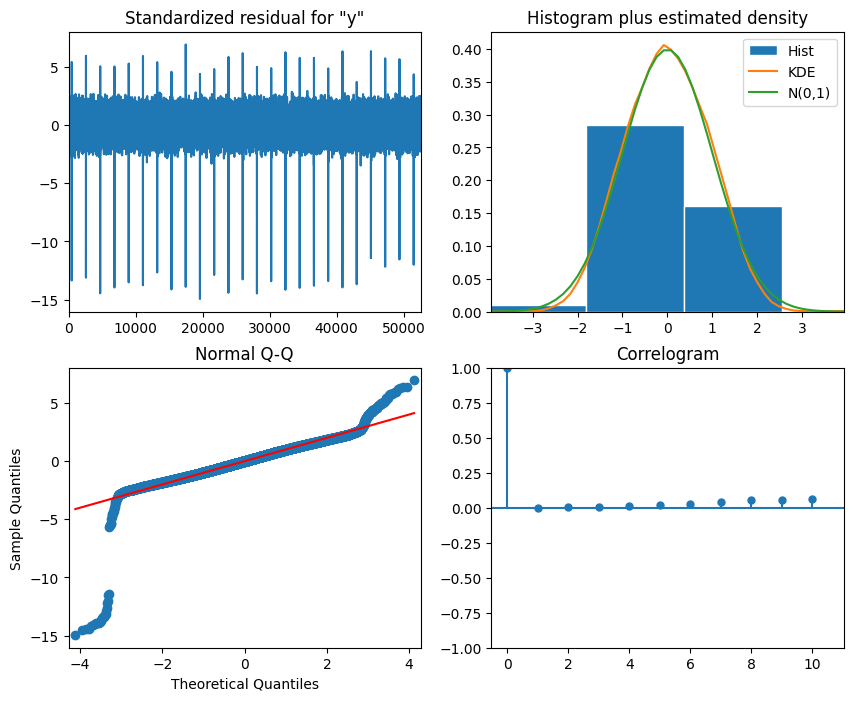

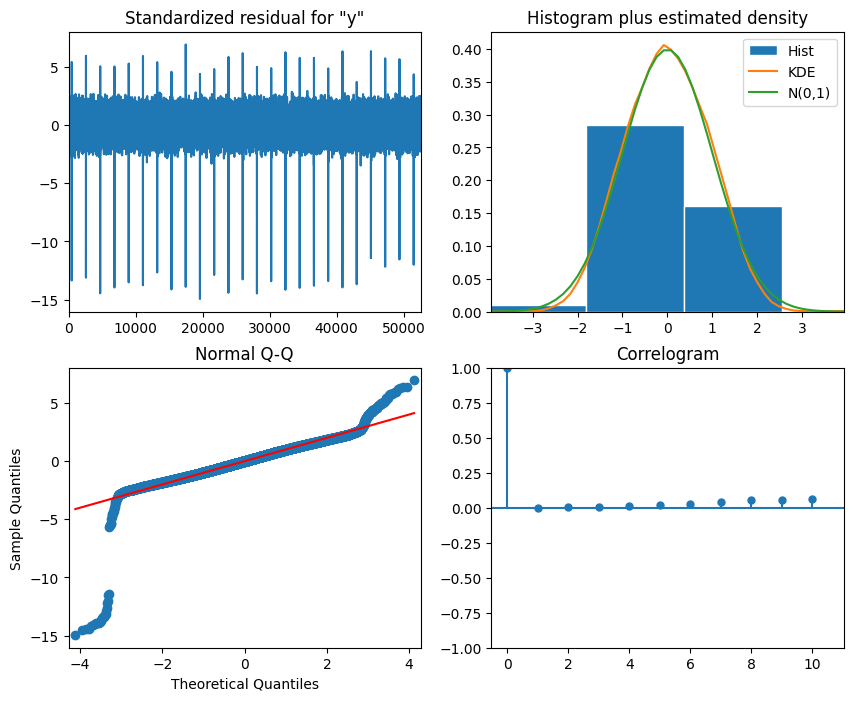

In [ ]:
ARMA_with_seasonality_1.plot_diagnostics(figsize=(10,8))

In [ ]:
residuals = ARMA_with_seasonality_1.resid #This is where residuals are stored.
print( acorr_ljungbox(residuals, np.arange(1, 11, 1)))

      lb_stat     lb_pvalue
1    1.815772  1.778174e-01
2    1.902171  3.863215e-01
3    2.202574  5.314416e-01
4    2.700291  6.091637e-01
5    2.706846  7.450711e-01
6   10.433909  1.075287e-01
7   18.110448  1.148150e-02
8   27.571855  5.628934e-04
9   43.973480  1.427403e-06
10  63.520764  7.768707e-10


### 12'25 Hours seasonality

In [14]:
descomposicion = seasonal_decompose(train['Water_Level_ODM'], model='additive', period=75)
serie_ajustada = train['Water_Level_ODM'] - descomposicion.seasonal

#Use the same p and q we get for ARMA AIC test
ARMA_with_seasonality_2 = SARIMAX(serie_ajustada, order=(14,0,8), simple_differencing=False).fit(disp=False)

c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


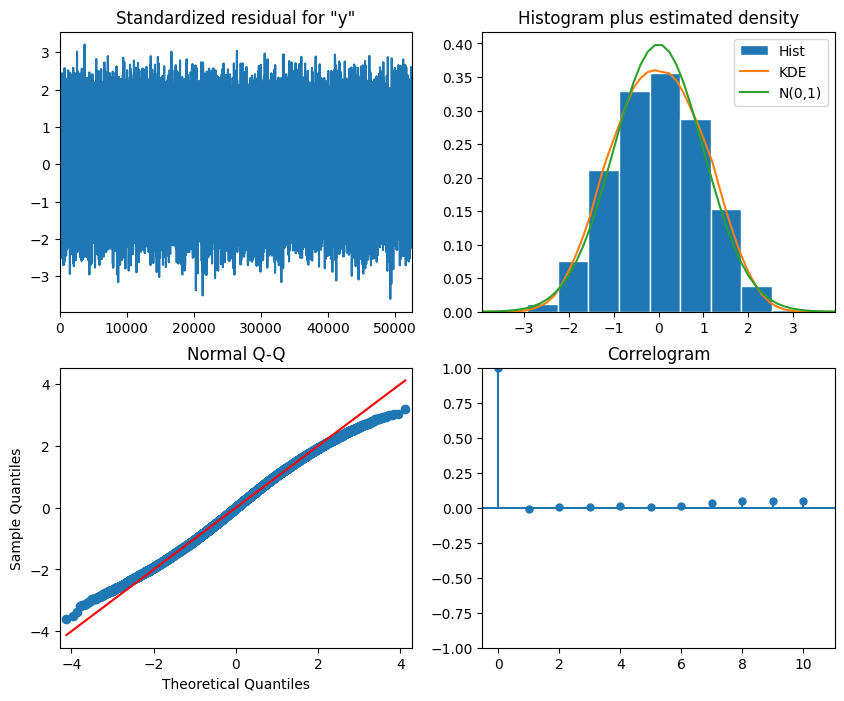

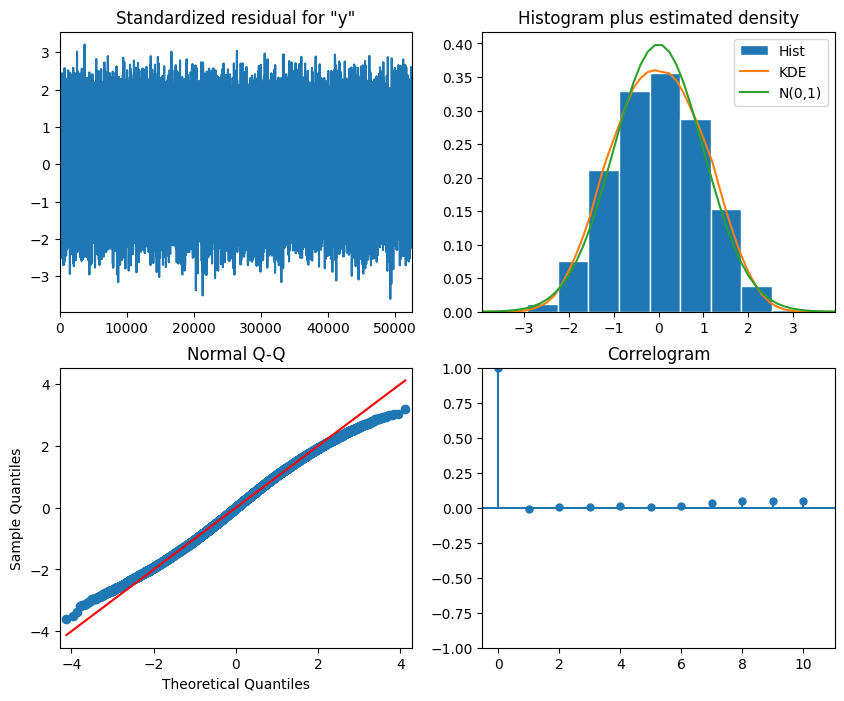

In [ ]:
ARMA_with_seasonality_2.plot_diagnostics(figsize=(10,8))

In [ ]:
residuals = ARMA_with_seasonality_2.resid #This is where residuals are stored.
print( acorr_ljungbox(residuals, np.arange(1, 11, 1)))

      lb_stat  lb_pvalue
1    0.040240   0.841012
2    0.082530   0.959575
3    0.137669   0.986962
4    0.401005   0.982395
5    1.787357   0.877716
6    3.424982   0.753922
7    7.720547   0.357880
8   13.230791   0.104152
9   25.242965   0.002714
10  38.169187   0.000035


### 24'50 Hours seasonality

In [ ]:
descomposicion = seasonal_decompose(train['Water_Level_ODM'], model='additive', period=149)
serie_ajustada = train['Water_Level_ODM'] - descomposicion.seasonal

ARMA_with_seasonality_3 = SARIMAX(serie_ajustada, order=(14,0,8), simple_differencing=False).fit(disp=False)

c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


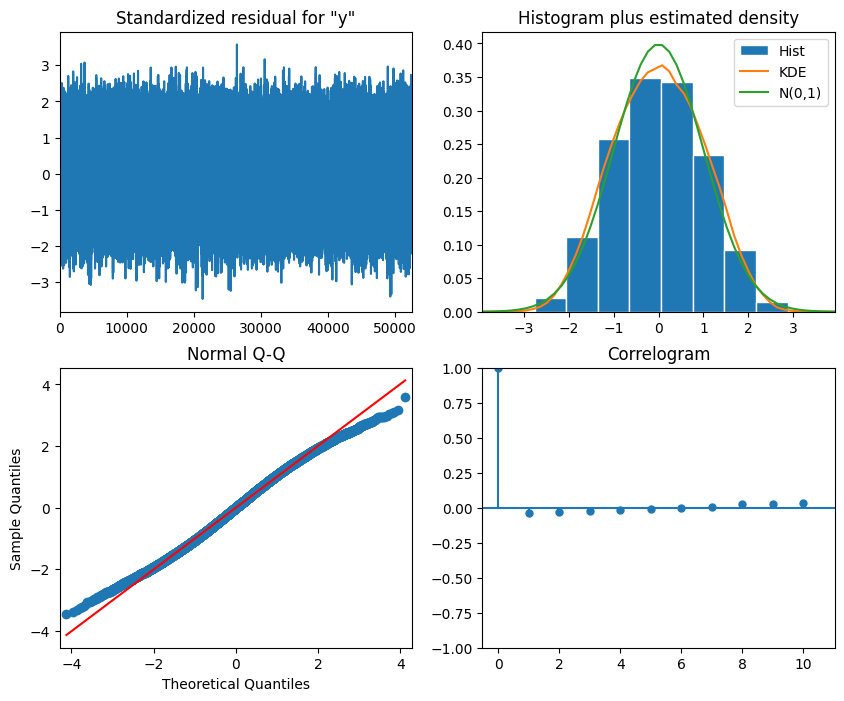

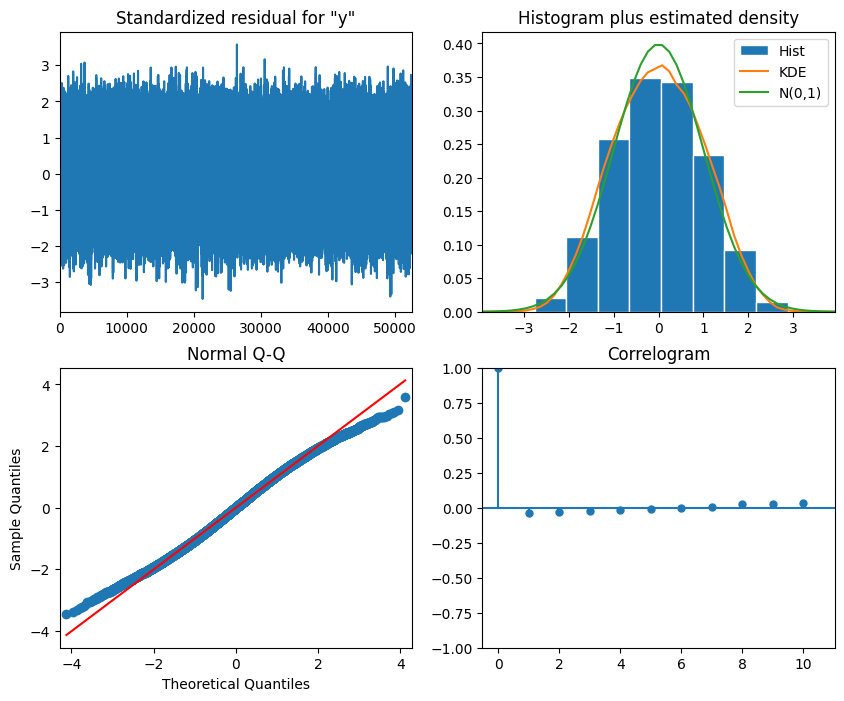

In [ ]:
ARMA_with_seasonality_3.plot_diagnostics(figsize=(10,8))

In [ ]:
residuals = ARMA_with_seasonality_3.resid #This is where residuals are stored.
print( acorr_ljungbox(residuals, np.arange(1, 11, 1)))

       lb_stat     lb_pvalue
1   242.464162  1.141352e-54
2   268.781374  4.313861e-59
3   280.491633  1.657509e-60
4   284.483717  2.405557e-60
5   294.007374  1.944867e-61
6   294.040158  1.547469e-60
7   295.169886  6.502366e-60
8   307.689005  9.501061e-62
9   326.359589  6.606347e-65
10  355.287706  3.006618e-70


## SARIMA

In [11]:
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX

def optimize_SARIMA(endog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []

    for order in tqdm_notebook(order_list):
        try:
            model = SARIMAX(
                endog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue

        aic = model.aic
        results.append([order, aic])

    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']

    #Return the AIC values in ascending order.
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)

    return result_df

In [12]:
ps = range(0, 3, 1)
qs = range(0, 3, 1)
Ps = range(0, 3, 1)
Qs = range(0, 3, 1)

SARIMA_order_list = list(product(ps, qs, Ps, Qs))

### 12'25 Hours seasonality

In [ ]:
#We will not consider the others seasonalities as the execution time for this spent 2 days
SARIMA_2 = optimize_SARIMA(train['Water_Level_ODM'], SARIMA_order_list, 0, 0, 75)
SARIMA_2 

C:\Users\angel\AppData\Local\Temp\ipykernel_19248\2204905546.py:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for order in tqdm_notebook(order_list):


  0%|          | 0/81 [00:00<?, ?it/s]

c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib

,"(p,q,P,Q)",AIC
0,"(2, 2, 0, 1)",-425208.447910
1,"(2, 2, 0, 0)",-424843.086776
2,"(2, 0, 0, 0)",-371665.628262
3,"(2, 0, 0, 1)",-371663.628263
4,"(2, 1, 0, 0)",-355178.518683
5,"(1, 2, 0, 1)",-252938.278511
6,"(1, 2, 0, 0)",-223856.997076
7,"(1, 1, 0, 1)",-220592.887223
8,"(1, 1, 0, 0)",-179432.839314
9,"(2, 1, 0, 1)",-172565.215632


0.    (p,q,P,Q) ---   AIC
1.  (2, 2, 0, 1)	-425208.447910
2.  (2, 2, 0, 0)	-424843.086776
3.  (2, 0, 0, 0)	-371665.628262
4.  (2, 0, 0, 1)	-371663.628263
    ...            ...

In [16]:
SARIMA_forecast= SARIMAX(train['Water_Level_ODM'], order=(2, 0, 2), seasonal_order=(0, 0, 1, 75), simple_differencing=False).fit(disp=False)

c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


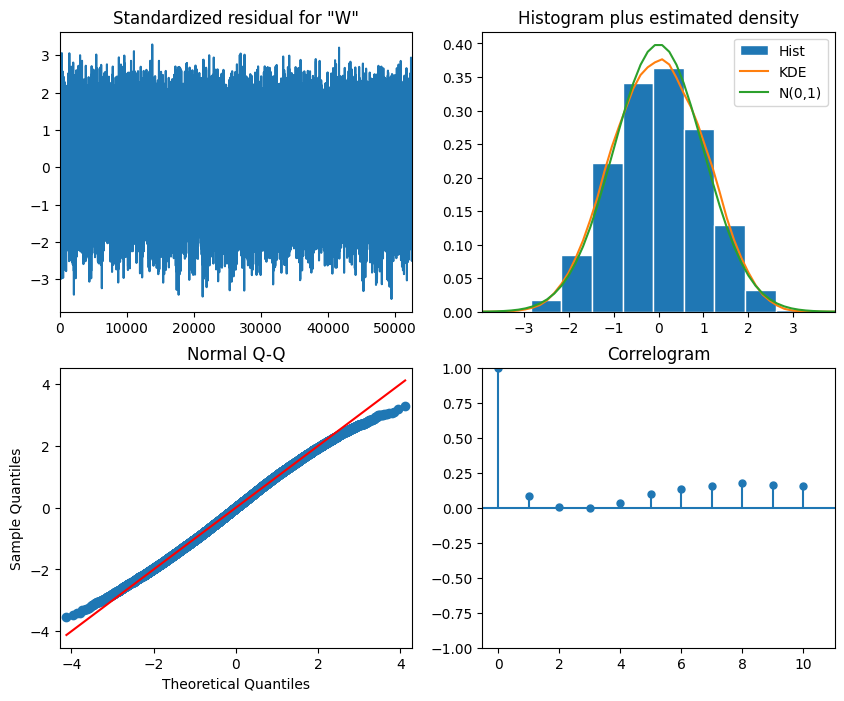

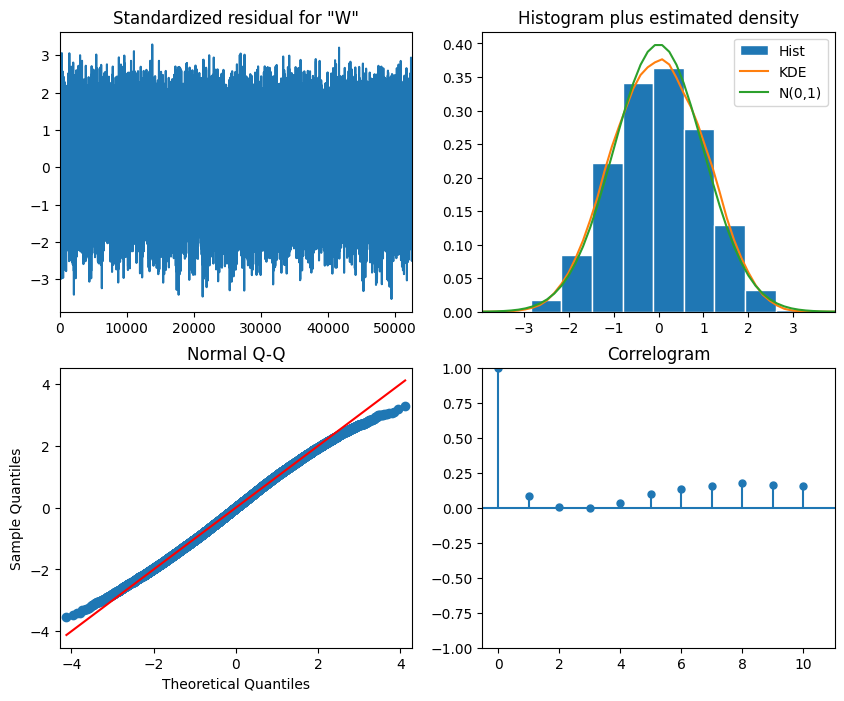

In [20]:
SARIMA_forecast.plot_diagnostics(figsize=(10,8))

In [21]:
residuals = SARIMA_forecast.resid
print( acorr_ljungbox(residuals, np.arange(1, 11, 1)))

       lb_stat      lb_pvalue
1    37.529998   9.001781e-10
2    37.553219   7.005225e-09
3    37.574389   3.478082e-08
4    44.751970   4.477166e-09
5    83.819112   1.331048e-16
6   205.928207   1.037612e-41
7   362.982429   2.046069e-74
8   544.411525  2.060038e-112
9   714.659375  4.875834e-148
10  870.646202  1.320124e-180


- nice resual distribution and qq plot shape, but the correlation between residuals is concerning
- p<0,05 at each of them tells the model is as good as it could be

## FB Prophet

documentation in: https://facebook.github.io/prophet/docs/quick_start.html#python-api

In [22]:
train_2 = train.copy()
# train_2 = train_2.drop(columns=['longitude', 'latitude', 'stationID', 'Water_Level'])
# PF Prophet algorithms requires time column to be names 'ds' and the one to predict 'y'
train_2 = train_2.rename(columns={'time': 'ds', 'Water_Level_ODM': 'y'})

train_2['ds'] = train_2['ds'].dt.tz_localize(None)  # Remove timezone for prophet

In [23]:
# Initialize Prophet with strong seasonality (since prior_scale=10)
prophet_model = Prophet(
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0,
    seasonality_mode='additive',
    yearly_seasonality=False,       # Disable defaults if adding manually
    weekly_seasonality=False,
    daily_seasonality=False
)

# Add the seasonalitites we are trying to analyze to the model

# (1) 12.25-hour seasonality (12h 25m)
prophet_model.add_seasonality(
    name='12h15m',
    period=12.25 / 24, 
    fourier_order=5     
)

# (2) 24.50-hour seasonality (24h 50m)
prophet_model.add_seasonality(
    name='daily',
    period=24.50 / 24,    
    fourier_order=5   
)

# (3) Custom 3.5-day cycle (e.g., biweekly pattern)
prophet_model.add_seasonality(
    name='2 weekly',
    period=14.76,       
    fourier_order=5
)

# Fit the model
prophet_model.fit(train_2)

23:55:17 - cmdstanpy - INFO - Chain [1] start processing
23:55:25 - cmdstanpy - INFO - Chain [1] done processing


In [24]:
future = prophet_model.make_future_dataframe(
    periods=7 * 24 * 6,  # 7 days * 24 hours * 6 intervals per hour (10 mins each)
    freq='10T',          # '10T' = 10 minutes
    include_history=False  # Optional: exclude training data
)
future.tail()

c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  dates = pd.date_range(


,ds
1003,2018-01-07 23:10:00
1004,2018-01-07 23:20:00
1005,2018-01-07 23:30:00
1006,2018-01-07 23:40:00
1007,2018-01-07 23:50:00


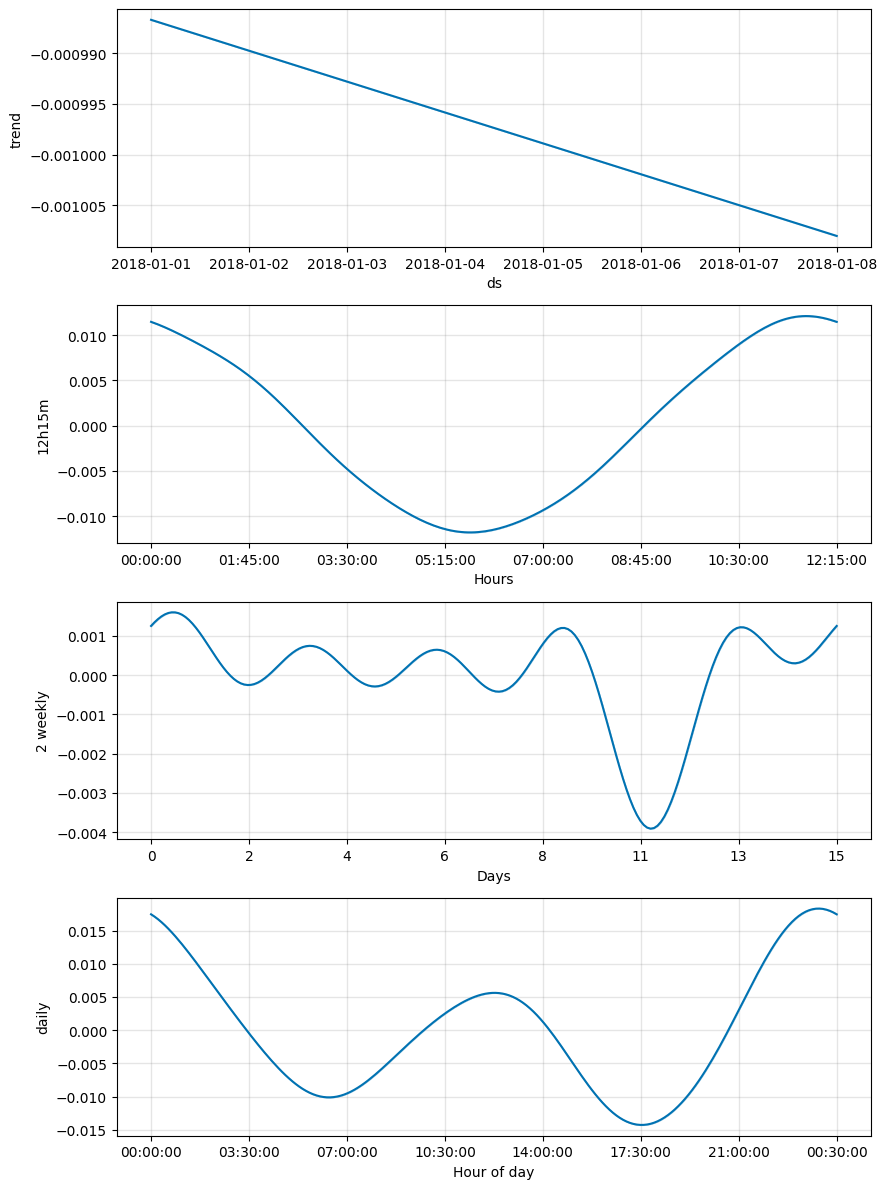

In [25]:
forecast = prophet_model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()
fig2 = prophet_model.plot_components(forecast)

Trend: the model understands that for the first week of 2018 there is a very light negative trend and predicts the possible error rates.
First: understands the existence of high and low wides.
Second: detect a harder low wide once every 2 weeks.
Third: detects the two high wides and the 2 low ones every day and the differences it can contain.

## Forecasting summary and results discussion

In [31]:
# Forecast 1008 steps ahead (10-min intervals = 7 days)

## ARMA(14,8) ##
ARMA_forecast = ARMA_model_fit.get_forecast(steps=1008)
pred_ARMA = ARMA_forecast.predicted_mean

# Optional: Add 2018 timestamps to the forecast
pred_ARMA.index = pd.date_range(
    start='2018-01-01 00:00:00+00:00',
    periods=1008,
    freq='10T'  # 10-minute frequency
)

test['ARMA_pred'] = pred_ARMA.values

## ARIMA(14,0,8) manual 12'25ly seasonality ## 

ARIMA_forecast = ARMA_with_seasonality_2.get_forecast(steps=1008)  # 1008 steps = 7 days
pred_ARIMA = ARIMA_forecast.predicted_mean

# Optional: Add 2018 timestamps to the forecast
pred_ARIMA.index = pd.date_range(
    start='2018-01-01 00:00:00+00:00',
    periods=1008,
    freq='10T'  # 10-minute frequency
)

SARIMA_forecast_vals = SARIMA_forecast.get_forecast(steps=1008)  # 1008 steps = 7 days
pred_SARIMA = SARIMA_forecast_vals.predicted_mean

# Optional: Add 2018 timestamps to the forecast
pred_SARIMA.index = pd.date_range(
    start='2018-01-01 00:00:00+00:00',
    periods=1008,
    freq='10T'  # 10-minute frequency
)

test['SARIMA_pred'] = pred_ARIMA.values

pred_PFProphet = prophet_model.predict(future)
test['PF_Prophet_pred'] = pred_PFProphet['yhat'].values

c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\angel\AppData\Local\Temp\ipykernel_6320\2890518600.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  pred_ARMA.index = pd.date_range(
C:\Users\angel\AppData\Local\Temp\ipykernel_6320\2890518600.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in

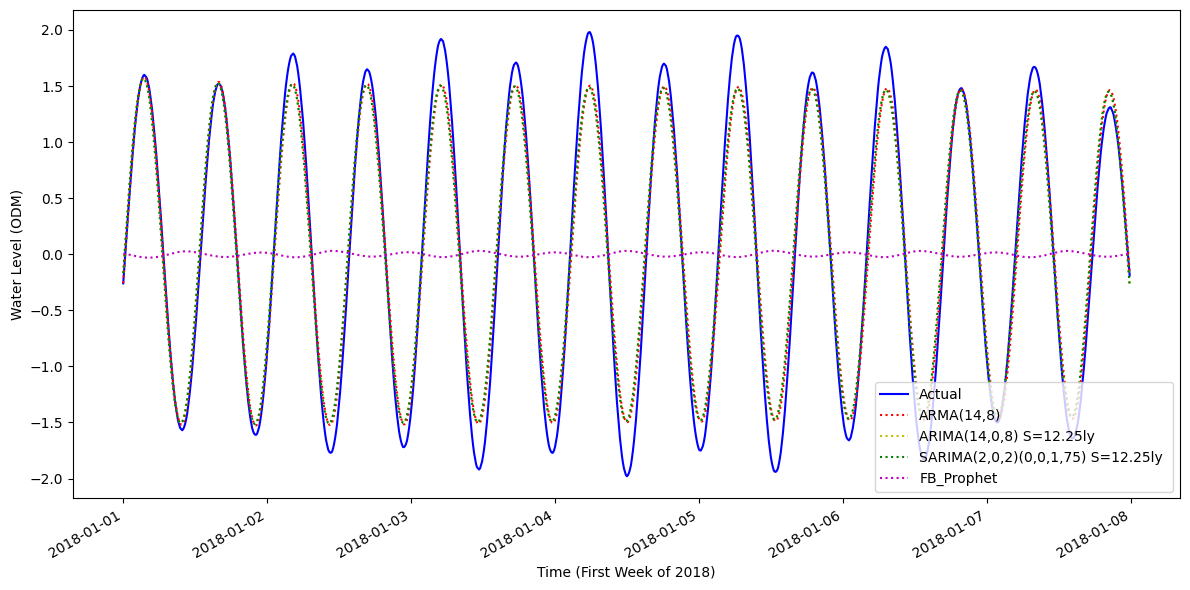

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot actual vs. predicted
ax.plot(test['time'], test['Water_Level_ODM'], 'b-', label='Actual')
ax.plot(test['time'], test['ARMA_pred'], 'r:', label='ARMA(14,8)')
ax.plot(test['time'], test['ARIMA_pred'], 'y:', label='ARIMA(14,0,8) S=12.25ly ')
ax.plot(test['time'], test['SARIMA_pred'], 'g:', label='SARIMA(2,0,2)(0,0,1,75) S=12.25ly')
ax.plot(test['time'], test['PF_Prophet_pred'], 'm:', label='FB_Prophet')

# Customize x-axis for 2018 timestamps
ax.set_xlabel('Time (First Week of 2018)')
ax.set_ylabel('Water Level (ODM)')
ax.legend(loc='best')

# Auto-format dates
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

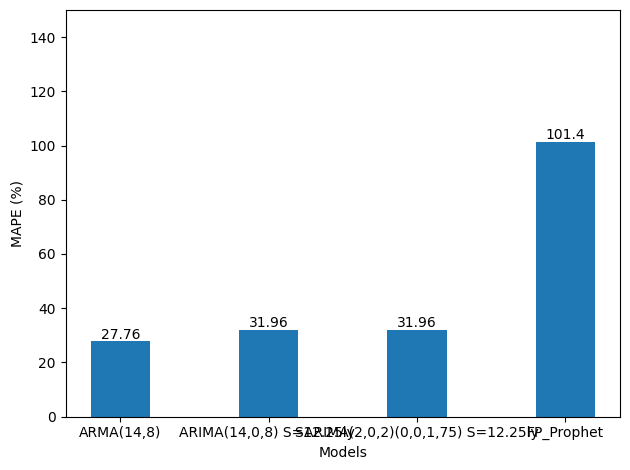

In [52]:
mape_ARMA = mean_absolute_percentage_error(test['Water_Level_ODM'], test['ARMA_pred'])
mape_ARIMA = mean_absolute_percentage_error(test['Water_Level_ODM'], test['ARIMA_pred'])
mape_SARIMA = mean_absolute_percentage_error(test['Water_Level_ODM'], test['SARIMA_pred'])
mape_FP_Prophet = mean_absolute_percentage_error(test['Water_Level_ODM'], test['PF_Prophet_pred'])

fig, ax = plt.subplots()
x = ['ARMA(14,8)', 'ARIMA(14,0,8) S=12.25ly ', 'SARIMA(2,0,2)(0,0,1,75) S=12.25ly', 'FP_Prophet']
y = [mape_ARMA*100, mape_ARIMA*100, mape_SARIMA*100, mape_FP_Prophet*100]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Models')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 150)

for index, value in enumerate(y):
    plt.text(x=index, y=value + 1, s=str(round(value,2)), ha='center')

plt.tight_layout()  

Interesting findings:

We spected to find clear seasonalitites when analyzing the seasonal decomposition. We also thought the more complex the model was it would predict better at the forecasting task. In addition, not every seasonality has the same importance. 

We decided to use the FP_prophet algorithm as it was an easy to implement model that was able to adapt to various seasonalities at the same time. However, the results we obtained were terrible!. ARMA model, the most simple one, was the one with lower MAPE, this means applying the seasonalities only made the models disorient, it adapts the better to when the wides start decreasing and when it increases again. 

Lessons learned: 

The main challenge we faced during the project was making conclusions from the different plots and accepting or rejecting the tests. Finally, we were able to understand and moving forward by reading the class slides and putting attention in them. The colabs were pretty easy to follow too. 

The time series forecasting models we have seen in class and functions and we have for their implementations are powerful tools not just for the final result, there are really useful to understant our time series and their behaviour.

